In [8]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
plt.style.use('science')
from pathlib import Path

class RecordLayerData(object):
    def __init__(self, data):
        data.replace('-', np.nan, inplace=True)  # 50SF数据会在温度上出现'-'
        data.ffill()
        # data 为pd.DataFrame groupby之后的数据
        self.raw_data = data
        self.data = data.groupby('CycleNo')
        self.cycle_no = np.array(list(self.data.groups.keys()))
        self.cycle_index = {}
        for i, cycle_no in enumerate(self.cycle_no):
            self.cycle_index[cycle_no] = i

        self.Qc_capacity = []
        self.Qd_capacity = []
        for i in self.cycle_no:  # 遇到0IJCBA0P011131BBW0000097时原来的会出bug
            self.Qc_capacity.append(self.data.get_group(i)['Qc'].max())
            self.Qd_capacity.append(self.data.get_group(i)['Qd'].max())
        self.Qc_capacity = np.array(self.Qc_capacity)
        self.Qd_capacity = np.array(self.Qd_capacity)

    def __getitem__(self, item):
        return self.data.get_group(self.cycle_no[item])

    def __len__(self):
        return len(self.cycle_no)

    def to_index(self, cycle_no):
        index = []
        for i in cycle_no:
            try:
                index.append(self.cycle_index[i])
            except KeyError:
                index.append(None)
        return index

    @property
    def SOH(self):
        cycle_data = self.cycle_capacity
        return cycle_data / cycle_data

    @property
    def cycle_capacity(self):
        return self.Qc_capacity

    def get_cycle_capacity(self):
        cycle_data = []
        for i in range(self.__len__()):
            cycle_data.append(self[i]['Qc'].max())
        return np.array(cycle_data)

    def get_step_data(self, item):
        cycle_data = self[item]
        step_data = cycle_data.groupby('StepNo')
        return step_data

    def get_data(self, start, end):
        cycle_data = []
        for i in range(start, end):
            cycle_data.append(self[i])
        cycle_data = pd.concat(cycle_data)
        return cycle_data

    def get_charge_data(self, item, cycle=False):
        if cycle:
            cycle_data = self.data.get_group(item)
        else:
            cycle_data = self[item]

        cycle_data = cycle_data.loc[cycle_data['state'] == 1, :]  # 提取充电段
        return cycle_data

    def get_discharge_data(self, item, cycle=False):
        if cycle:
            cycle_data = self.data.get_group(item)
        else:
            cycle_data = self[item]
        cycle_data = cycle_data.loc[cycle_data['state'] == 2, :]  # 提取放电段
        return cycle_data

    def get_idle_data(self, item):
        cycle_data = self[item]
        step_data = cycle_data.groupby('StepNo')
        step_no = list(step_data.groups.keys())
        state = list(step_data['state'].nth(0))
        before_state = None
        idle_data = {'charge': [], 'discharge': []}
        for i, step_state in enumerate(state):
            if (step_state == 0) & (before_state == 1):
                idle_data['charge'].append(step_data.get_group(step_no[i]))
                before_state = step_state
            elif (step_state == 0) & (before_state == 2):
                idle_data['discharge'].append(step_data.get_group(step_no[i]))
                before_state = step_state
            else:
                before_state = step_state
        return idle_data

    def to_pickle(self, filename):
        self.raw_data.to_pickle(filename)

    @classmethod
    def load_pickle(cls, filename):
        data = pd.read_pickle(filename)
        return cls(data)


# 读取对标数据

In [13]:
barcode_df = pd.read_excel('对标数据.xlsx', index_col=0)
dataset_dict = {'25℃': ['0.1P', '0.25P', '0.5P', '1P'], '35℃': ['1P'], '45℃': ['1P']}
record_layer_dir = Path(r'record_layer')
record_layer_data: dict[str, dict[str, RecordLayerData]] = {}
for key, value in dataset_dict.items():
    record_layer_data[key] = {}
    for var in value:
        barcode = barcode_df[var].loc[key]
        record_layer_data[key][var] = pd.read_csv(record_layer_dir / ('record_layer_%s.csv' % barcode))
        record_layer_data[key][var] = RecordLayerData(record_layer_data[key][var])

max_idx = pd.read_excel('对标数据.xlsx', index_col=0, sheet_name='容量最高循环')
max_capacity_index = int(max_idx['0.5P'].loc['25℃'])
charge_data = record_layer_data['25℃']['0.5P'].get_charge_data(max_capacity_index)
discharge_data = record_layer_data['25℃']['0.5P'].get_discharge_data(max_capacity_index)
idle_data = record_layer_data['25℃']['0.5P'].get_idle_data(max_capacity_index)
all_data = record_layer_data['25℃']['0.5P'].data.get_group(max_capacity_index)

# 初始化参数

In [16]:
sigma = pd.read_csv(r'.\params\E_sigma.csv', header=None)
Ds = pd.read_csv(r'.\params\E_DL_int1.csv', header=None)
transNum = pd.read_csv(r'.\params\E_transpNm.csv', header=None)
LFP = pd.read_csv(r'.\params\LFP.csv', header=None)
Gr_charge = pd.read_csv(r'.\params\Gr_discharge.csv', header=None)
Gr_discharge = pd.read_csv(r'.\params\Gr_charge.csv', header=None)

LFP_func = interp1d(LFP[0], LFP[1], fill_value='extrapolate')
Gr_charge_func = interp1d(Gr_charge[0], Gr_charge[1], fill_value='extrapolate')
Gr_discharge_func = interp1d(Gr_discharge[0], Gr_discharge[1], fill_value='extrapolate')

soc = np.linspace(0, 1, 500)
LFP = LFP_func(soc)
Gr_charge = Gr_charge_func(soc)
Gr_discharge = Gr_discharge_func(soc)

Ds_x = Ds[0].to_numpy()
Ds_y = Ds[1].to_numpy()
sigma_x = sigma[0].to_numpy()
sigma_y = sigma[1].to_numpy()
transNum_x = transNum[0].to_numpy()
transNum_y = transNum[1].to_numpy()

F = 96485.33212
CB = 1.126
rho_neg = 2.2279
rho_pos = 3.488
c_max_pos = rho_pos * 0.972 * 1e6 * 144 / 1000 * 3600 / F
c_max_neg = rho_neg * 0.967 * 1e6 * 340 / 1000 * 3600 / F * 1.036
epss_neg = 1.55 / rho_neg
epss_pos = 2.45 / rho_pos
epsl_neg = 1 - epss_neg / 0.967
epsl_pos = 1 - epss_pos / 0.972
ah_neg = c_max_neg * 10.1e-05 * 0.1875 * 17.06216 * F * epss_neg * 2 / 3600
ah_pos = c_max_pos * 13.5e-05 * 0.1875 * 17.06216 * F * epss_pos * 2 / 3600
print(c_max_pos, c_max_neg, epss_neg, epss_pos, epsl_neg, epsl_pos, ah_neg, ah_pos)

18215.724025431275 28314.05326228771 0.6957224291934109 0.702408256880734 0.28053523351250165 0.27735776041076743 341.1799462476224 296.20602483696


# 调参

In [17]:
K_LFP_func_x = np.array([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1])
K_LFP_func_y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
K_Gr_func_x = np.array([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1])
K_Gr_func_y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

D_LFP_func_x = np.array([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1])
D_LFP_func_y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
D_Gr_func_x = np.array([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1])
D_Gr_func_y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


def LFP_diffusivity(sto, T):
    D_ref = 1.2e-16 * 5
    E_D_s = 3.03e4
    # D_revise = pybamm.Interpolant(D_LFP_func_x, D_LFP_func_y, sto, interpolator="linear", extrapolate=False) # 用插值会出现bug
    arrhenius = np.exp(E_D_s / pybamm.constants.R * (1 / 298.15 - 1 / T))
    D_revise = 1
    return D_revise * D_ref * arrhenius


def Gr_diffusivity(sto, T):
    D_ref = 1.06e-13 * 5
    E_D_s = 3.03e4
    D_revise = pybamm.Interpolant(D_Gr_func_x, D_Gr_func_y, sto, interpolator="linear", extrapolate=False)
    # D_revise = D_ref
    # E_D_s not given by Chen et al (2020), so taken from Ecker et al. (2015) instead
    arrhenius = np.exp(E_D_s / pybamm.constants.R * (1 / 298.15 - 1 / T))
    # arrhenius = 1
    return D_revise * D_ref * arrhenius


def graphite_exchange_current_density(c_e, c_s_surf, c_s_max, T):
    sto = c_s_surf / c_s_max
    c_l_ref = 1e3 
    m_ref = 6.06e-10 * 5 # (A/m2)(m3/mol)**1.5 - includes ref concentrations
    E_r = 35000
    arrhenius = np.exp(E_r / pybamm.constants.R * (1 / 298.15 - 1 / T))
    # arrhenius = 1
    K_revise = pybamm.Interpolant(K_Gr_func_x, K_Gr_func_y, sto, interpolator="linear")
    # K_revise = 1
    return m_ref * arrhenius * (c_e / c_l_ref) ** 0.5 * c_s_surf ** 0.5 * (c_s_max - c_s_surf) ** 0.5 * K_revise * F


def LFP_exchange_current_density(c_e, c_s_surf, c_s_max, T):
    sto = c_s_surf / c_s_max
    c_l_ref = 1e3
    m_ref = 5.56e-11 * 2  # (A/m2)(m3/mol)**1.5 - includes ref concentrations
    E_r = 35000
    arrhenius = np.exp(E_r / pybamm.constants.R * (1 / 298.15 - 1 / T))
    # arrhenius = 1
    K_revise = pybamm.Interpolant(K_LFP_func_x, K_LFP_func_y, sto, interpolator="linear")
    # K_revise = 1
    return m_ref * arrhenius * (c_e / c_l_ref) ** 0.5 * c_s_surf ** 0.5 * (c_s_max - c_s_surf) ** 0.5 * K_revise * F


def transfer_num(c_e, T):
    return pybamm.Interpolant(transNum_x, transNum_y, c_e, interpolator='cubic')


def electrolyte_conductivity(c_e, T):
    return pybamm.Interpolant(sigma_x, sigma_y, c_e, interpolator='cubic')


def electrolyte_diffusivity(c_e, T):
    return pybamm.Interpolant(Ds_x, Ds_y, c_e, interpolator='cubic')


def get_params(charge_state):
    if charge_state == 'charge':
        def LFP_ocp_Hithium280Ah(sto):
            return pybamm.Interpolant(soc, LFP + 0.015, sto, interpolator='cubic')

        def graphite_ocp_Hithium280Ah(sto):
            return pybamm.Interpolant(soc, Gr_charge - 0.01, sto, interpolator='cubic')
    elif charge_state == 'discharge':
        def LFP_ocp_Hithium280Ah(sto):
            return pybamm.Interpolant(soc, LFP - 0.015, sto, interpolator='cubic')

        def graphite_ocp_Hithium280Ah(sto):
            return pybamm.Interpolant(soc, Gr_discharge + 0.01, sto, interpolator='cubic')
    else:
        raise ValueError('Charge state must be "charge" or "discharge"')

    hithium_params = {
        # cell
        "Negative electrode thickness [m]": 10.1e-05,
        "Separator thickness [m]": 1.6e-05,
        "Positive electrode thickness [m]": 13.5e-05,
        "Negative particle radius [m]": 2.42e-6,
        "Positive particle radius [m]": 9.78e-7,
        "Electrode height [m]": 17.06216,
        "Electrode width [m]": 0.1875,
        "Nominal cell capacity [A.h]": 280,
        "Number of electrodes connected in parallel to make a cell": 2.0,
        "Maximum concentration in negative electrode [mol.m-3]": c_max_neg * 1.039,
        "Maximum concentration in positive electrode [mol.m-3]": c_max_pos * 1.063,
        "Positive electrode porosity": epsl_pos,
        "Positive electrode active material volume fraction": epss_pos,
        "Negative electrode porosity": epsl_neg,
        "Negative electrode active material volume fraction": epss_neg,
        'Separator porosity': 0.42,
        "Initial concentration in negative electrode [mol.m-3]": c_max_neg * 1.039 * 0.0138,
        "Initial concentration in positive electrode [mol.m-3]": c_max_pos * 1.063 * 0.947,
        "Lower voltage cut-off [V]": 2.5,
        "Upper voltage cut-off [V]": 3.65,
        "Open-circuit voltage at 0% SOC [V]": 2.5,
        "Open-circuit voltage at 100% SOC [V]": 3.65,
        # "Open-circuit voltage at 0% SOC [V]": 2.5,
        # "Open-circuit voltage at 100% SOC [V]": 3.65,
        "Negative electrode exchange-current density [A.m-2]"
        "": graphite_exchange_current_density,
        "Positive electrode exchange-current density [A.m-2]"
        "": LFP_exchange_current_density,
        'Electrolyte diffusivity [m2.s-1]': electrolyte_diffusivity,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity,
        # "Positive electrode diffusivity [m2.s-1]": 1.2e-16,
        # "Negative electrode diffusivity [m2.s-1]": 1.06e-14,
        "Positive electrode diffusivity [m2.s-1]": LFP_diffusivity,
        "Negative electrode diffusivity [m2.s-1]": Gr_diffusivity,
        "Positive electrode Bruggeman coefficient (electrode)": 1.5,
        "Positive electrode Bruggeman coefficient (electrolyte)": 1.5,
        "Negative electrode Bruggeman coefficient (electrolyte)": 1.5,
        "Negative electrode Bruggeman coefficient (electrode)": 1.5,
        "Positive electrode conductivity [S.m-1]": 100,
        "Negative electrode conductivity [S.m-1]": 4.453,
        "Initial concentration in electrolyte [mol.m-3]": 900.0,
        "Negative electrode OCP [V]": graphite_ocp_Hithium280Ah,
        "Positive electrode OCP [V]": LFP_ocp_Hithium280Ah,
        'Cation transference number': transfer_num,
        # 'Contact resistance [Ohm]': 1.002e-4,
        'Positive electrode double-layer capacity [F.m-2]': 0,
        'Negative electrode double-layer capacity [F.m-2]': 0,
    }
    return hithium_params


var_pts = {
    "x_n": 5,  # negative electrode
    "x_s": 5,  # separator
    "x_p": 5,  # positive electrode
    "r_n": 20,  # negative particle
    "r_p": 20,  # positive particle
}

safe_solver = pybamm.CasadiSolver(mode='safe', dt_max=50)
P = 0.5 * 896
# C = 0.5
exp_charge = pybamm.Experiment(
    [
        "Charge at %fW until 3.65V (0.5 minute period)" % P,
        "Rest for 10 minute (0.1 minute period)",
    ]
)
exp_discharge = pybamm.Experiment(
    [
        "Discharge at %fW until 2.5 V (0.5 minute period)" % P,  # ageing cycles
        "Rest for 10 minute (0.1 minute period)",
    ]
)
exp = pybamm.Experiment(
    [
        "Charge at %fW until 3.65 V (0.05 minute period)" % P,
    ]
)



# 与实验对标

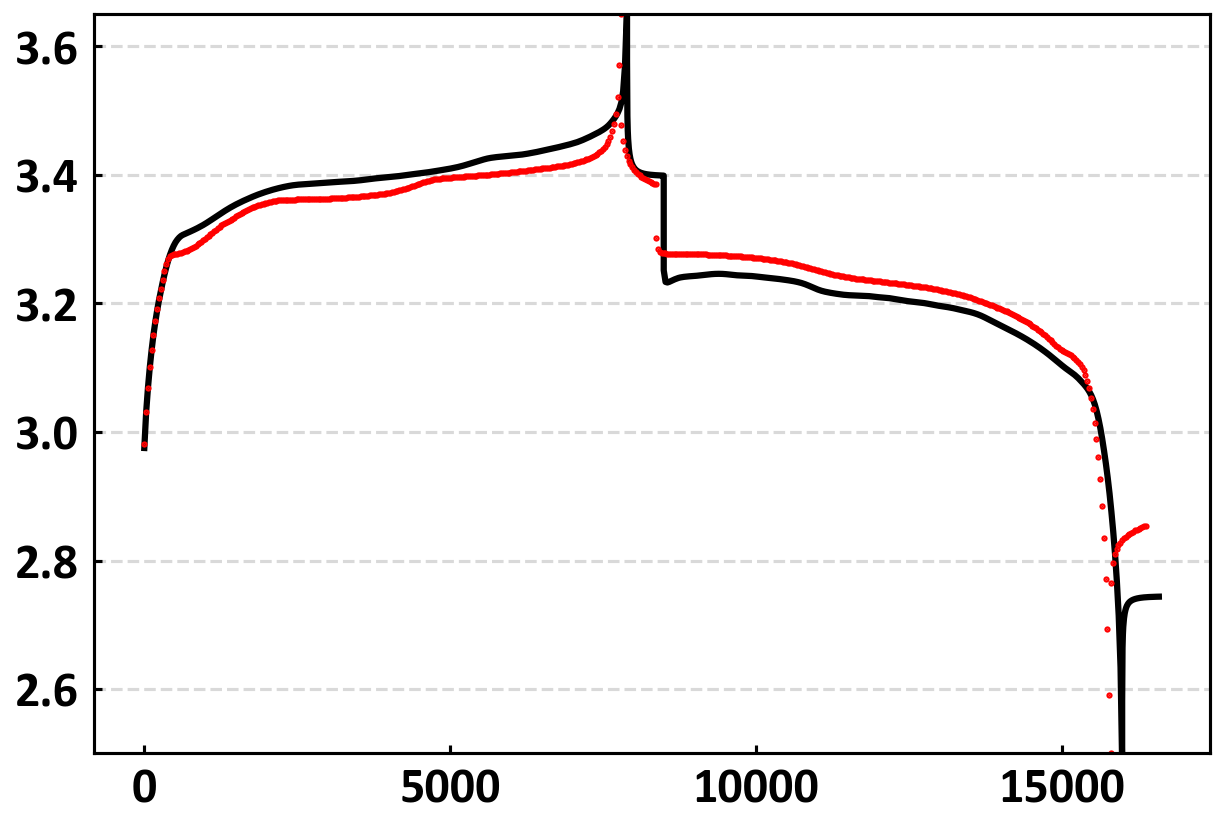

In [18]:
model = pybamm.lithium_ion.DFN()
param = model.default_parameter_values
param.update(get_params('charge'))
sim = pybamm.Simulation(model, parameter_values=param, var_pts=var_pts, solver=safe_solver, experiment=exp_charge)
sol: pybamm.Solution = sim.solve()
param.update(get_params('discharge'))
sim = pybamm.Simulation(model, parameter_values=param, var_pts=var_pts, solver=safe_solver, experiment=exp_discharge)
sol: pybamm.Solution = sim.solve(starting_solution=sol)

# plt.plot(sol['Throughput capacity [A.h]'].entries,
plt.plot(sol['Time [s]'].entries,
         sol['Voltage [V]'].entries - sol['Current [A]'].entries * 0.0001002)
plt.plot(all_data['t'], all_data['V'], 'ro', markersize=0.5)
# plt.plot(sim_cp_dict['0.5'][0], sim_cp_dict['0.5'][1], 'ro', markersize=0.5)
plt.ylim([2.5, 3.65])
plt.savefig('test.png')